In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import glob
import os

In [2]:
stem = '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart'

In [3]:
flat_file_names = glob.glob(stem + '/flat*.tiff')

In [4]:
sci_file_names = glob.glob(stem + '/*pt*.tiff')
sci_file_names = np.sort(sci_file_names)

In [5]:
sci_file_names

array(['/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/001pt5mw.tiff',
       '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/007pt5mw.tiff',
       '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/015pt0mw.tiff',
       '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/075pt0mw.tiff',
       '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/150pt0mw.tiff',
       '/Users/eckhartspalding/Dropbox/science_projects/nice_beam_profiler/data/20260303_eckhart/183pt0mw.tiff'],
      dtype='<U102')

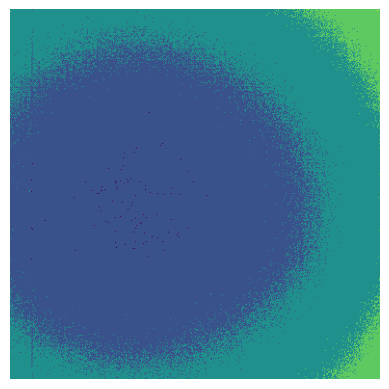

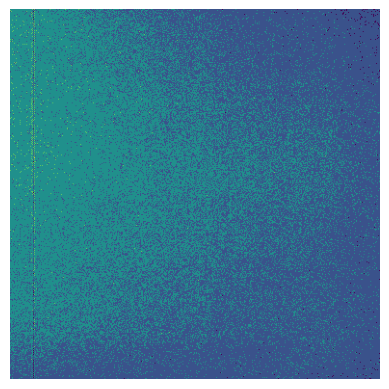

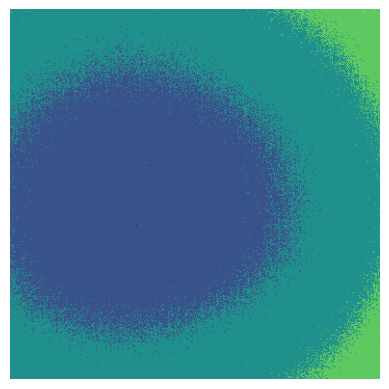

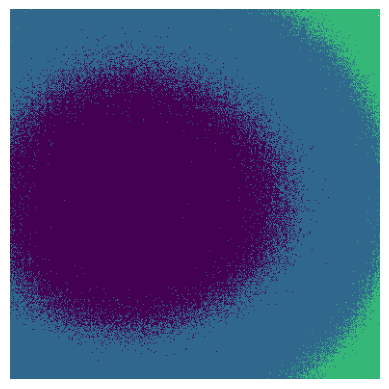

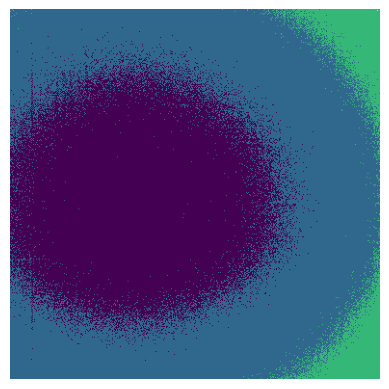

In [6]:
for flat_file_name in flat_file_names:
    test_frame = Image.open(flat_file_name)
    plt.imshow(test_frame)
    plt.axis('off')
    plt.show()

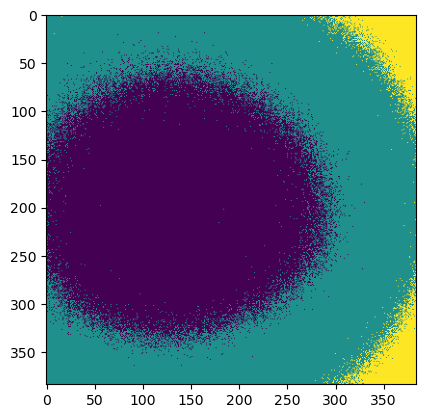

In [8]:
# take a median of the flats

flat_frames = []
for flat_file_name in flat_file_names:
    flat_frames.append(np.array(Image.open(flat_file_name)))
flat_median = np.median(flat_frames, axis=0)

plt.imshow(flat_median)
plt.show()


In [ ]:
sci_frame_bckgd_subted = sci_frame - flat_median

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [-1.  0.  0. ...  0.  0.  0.]
 ...
 [ 0. -1. -1. ...  0.  0.  0.]
 [-1. -1. -1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]]


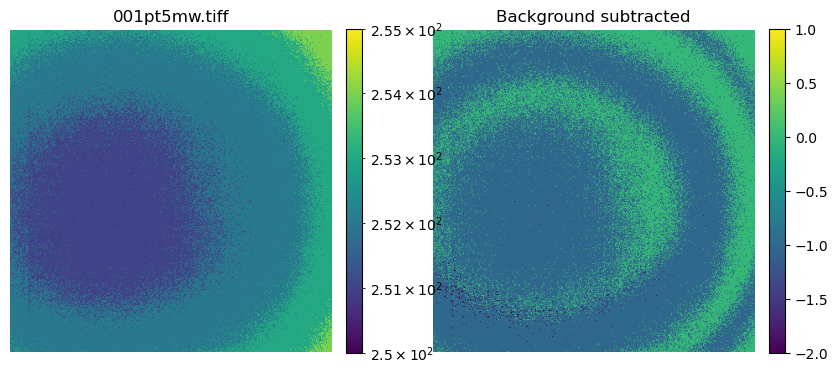

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  1.  0.  0.]
 [-1.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [-1.  0. -1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0. -1.]]


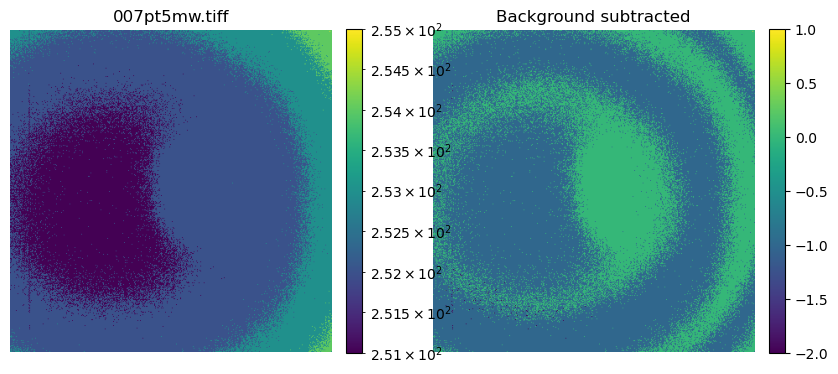

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  1.  0.  0.]
 [-1.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [-1.  0. -1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0. -1.]]


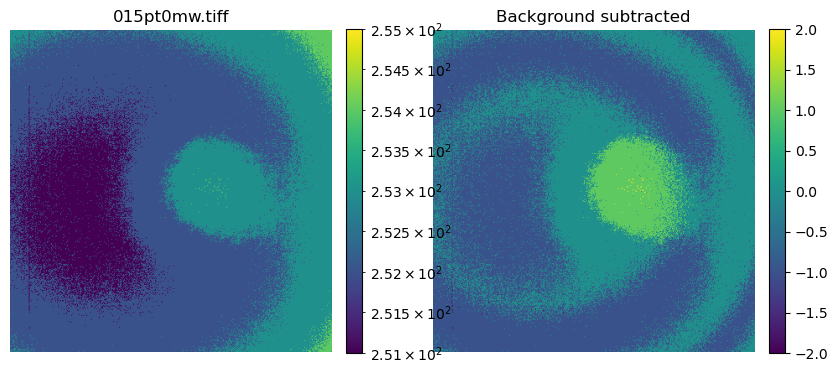

[[-10. -10. -10. ... -10. -10. -10.]
 [-10. -10. -10. ... -10. -10. -10.]
 [-11. -10. -10. ... -10. -10. -10.]
 ...
 [-10. -11. -11. ... -10. -10. -10.]
 [-11. -11. -11. ... -10. -10. -10.]
 [-11. -10. -11. ... -10. -10. -11.]]


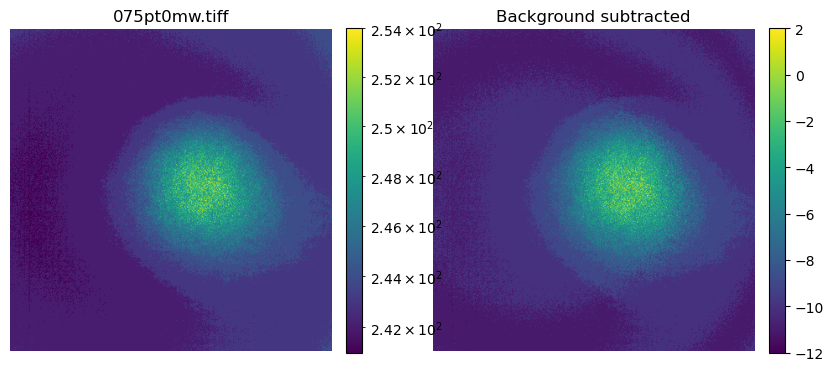

[[-23. -23. -22. ... -22. -22. -23.]
 [-23. -23. -23. ... -22. -23. -23.]
 [-23. -23. -23. ... -22. -23. -22.]
 ...
 [-23. -23. -23. ... -23. -23. -23.]
 [-23. -23. -23. ... -23. -23. -23.]
 [-23. -23. -23. ... -23. -23. -23.]]


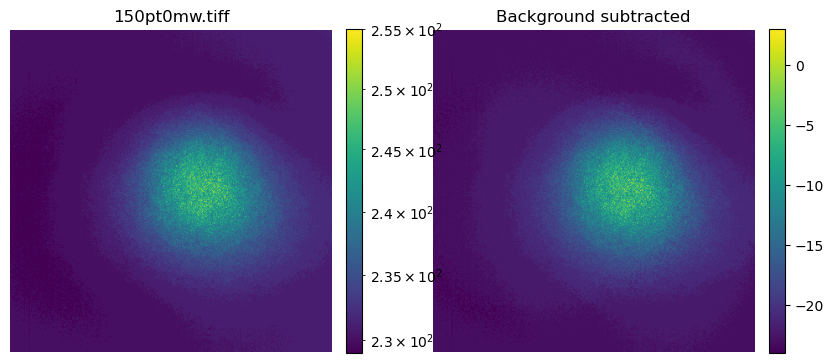

[[-28. -28. -27. ... -27. -27. -27.]
 [-28. -28. -28. ... -27. -27. -27.]
 [-28. -28. -28. ... -28. -27. -27.]
 ...
 [-28. -28. -28. ... -28. -28. -28.]
 [-28. -28. -28. ... -28. -28. -28.]
 [-28. -28. -28. ... -28. -28. -28.]]


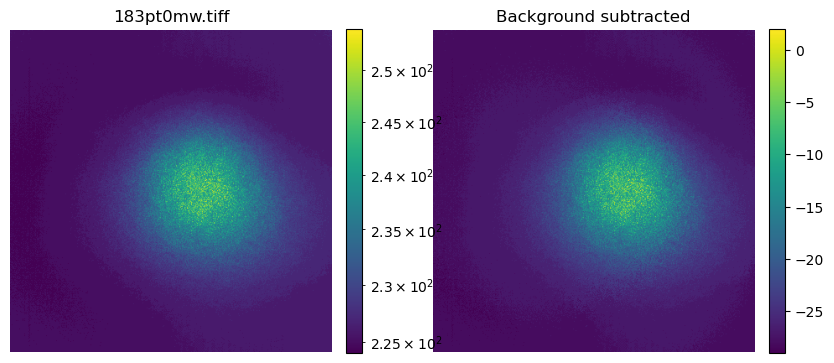

In [15]:
# no background-subtraction here

for sci_file_name in sci_file_names:
    sci_frame = Image.open(sci_file_name)
    
    sci_frame_bckgd_subted = sci_frame - flat_median
    print(sci_frame_bckgd_subted)
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    im0 = axs[0].imshow(sci_frame, norm=LogNorm())
    axs[0].set_title(os.path.basename(sci_file_name))
    axs[0].axis('off')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    im1 = axs[1].imshow(sci_frame - flat_median)
    axs[1].set_title("Background subtracted")
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.show()

In [39]:
np.max(sci_frame)

np.uint8(255)

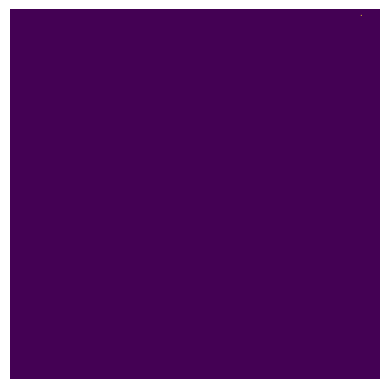

In [25]:
plt.imshow(test_frame)

plt.imshow(test_frame, norm=LogNorm())

plt.axis('off')
plt.show()

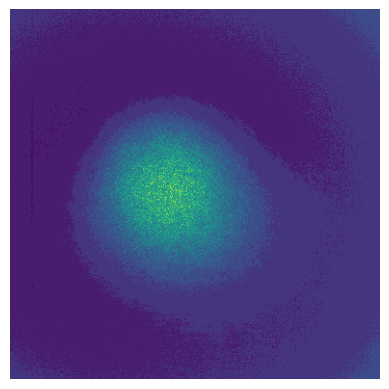

In [5]:
plt.imshow(img_0075)
plt.axis('off')
plt.show()

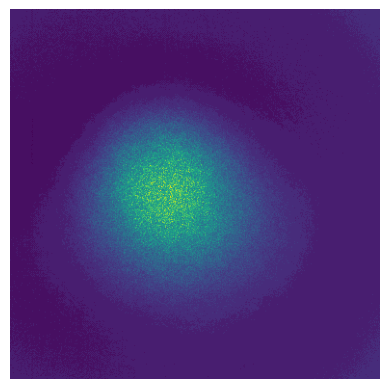

In [6]:
plt.imshow(img_0150)
plt.axis('off')
plt.show()

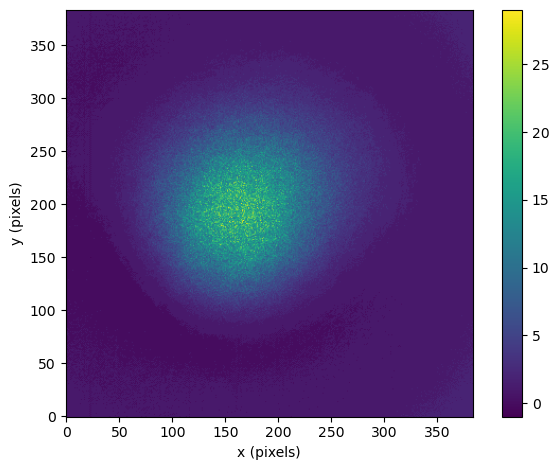

In [35]:
plt.imshow(img_0183, origin='lower')
plt.colorbar()
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.tight_layout()
plt.savefig('junk_readout.png')
#plt.show()

In [19]:
# crap background subtraction

img_0015 = np.array(img_0015).astype(np.float32)
img_0075 = np.array(img_0075).astype(np.float32)
img_0150 = np.array(img_0150).astype(np.float32)
img_0183 = np.array(img_0183).astype(np.float32)

img_0015 -= np.median(img_0015[:,0])
img_0075 -= np.median(img_0075[:,0])
img_0150 -= np.median(img_0150[:,0])
img_0183 -= np.median(img_0183[:,0])




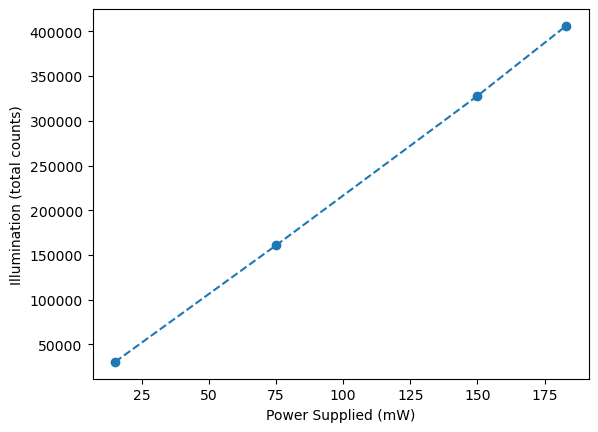

In [30]:
illum_summed = np.asarray([np.sum(img_0015), np.sum(img_0075), np.sum(img_0150), np.sum(img_0183)])
power_supplied = np.array([15, 75, 150, 183])

plt.clf()
plt.plot(power_supplied, illum_summed, marker='o', linestyle='--')
plt.xlabel('Power Supplied (mW)')
plt.ylabel('Illumination (total counts)')
plt.savefig('junk_illumination_fcn_of_power.png')
plt.show()



In [21]:
print(np.sum(img_0015))
print(np.sum(img_0075))
print(np.sum(img_0150))
print(np.sum(img_0183))





30425.0
160804.0
327805.0
406044.0


In [23]:
np.asarray([np.sum(img_0183), np.sum(img_0150), np.sum(img_0075), np.sum(img_0015)])

array([406044., 327805., 160804.,  30425.], dtype=float32)